# AgroÓrbit — Clustering dos Meses (K-Means)

Esse notebook usa Machine Learning não supervisionado para descobrir automaticamente
quais meses se parecem entre si, sem que a gente diga ao modelo quais são críticos.

**Algoritmo:** K-Means Clustering  
**Features:** focos, precipitação, umidade, temperatura, índice de risco  
**Bioma:** Caatinga — médias mensais das 130 microrregiões  
**Resultado:** Grupos de meses com comportamento climático similar

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

CAMINHO_DATA = '../data'
MESES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

print('bibliotecas carregadas!')

bibliotecas carregadas!


## 2. Preparando os dados

In [2]:
df = pd.read_csv(f'{CAMINHO_DATA}/dados_finais_3anos.csv')

# médias mensais dos 3 anos (Caatinga toda)
df_media = df.groupby('mes').agg(
    focos       = ('focos',   'mean'),
    precip      = ('precip',  'mean'),
    umidade     = ('umidade', 'mean'),
    temp        = ('temp',    'mean'),
    indice      = ('indice',  'mean'),
).reset_index()

df_media['mes_nome'] = MESES

print('Médias mensais calculadas (Caatinga toda):')
print(df_media[['mes_nome','focos','precip','umidade','temp','indice']].to_string(index=False))

Médias mensais calculadas (Caatinga toda):
mes_nome         focos     precip   umidade      temp   indice
     Jan  13595.000000  95.224333 66.019667 26.352333 0.312667
     Fev   7070.333333  95.431333 66.415333 26.510333 0.284667
     Mar   5567.000000 174.004333 66.965333 26.452000 0.208000
     Abr   4511.666667 129.861333 66.600000 26.408000 0.224000
     Mai   7281.333333  85.563000 66.649667 26.402333 0.301667
     Jun  10929.000000  72.514333 66.893667 26.375667 0.320667
     Jul  16060.333333  43.158000 66.477667 26.457333 0.385667
     Ago  29480.666667  22.038667 66.327000 26.520333 0.443333
     Set  81507.000000  10.998000 66.117333 26.657333 0.498667
     Out 127213.666667  11.195000 66.105000 26.557000 0.521000
     Nov  61738.333333  48.505000 65.629667 26.528000 0.469333
     Dez  50271.666667  48.244667 65.556667 26.674000 0.466667


## 3. Encontrando o número ideal de clusters

Usamos o método do cotovelo e o silhouette score para descobrir
quantos grupos fazem mais sentido nos dados.

In [3]:
FEATURES = ['focos', 'precip', 'umidade', 'temp', 'indice']
X = df_media[FEATURES].values

# normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# método do cotovelo + silhouette
inertias    = []
silhouettes = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

print('k  | Inércia  | Silhouette')
print('-' * 32)
for k, ine, sil in zip(k_range, inertias, silhouettes):
    print(f'{k}  | {ine:>8.2f} | {sil:.3f}')

melhor_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'\nMelhor número de clusters: {melhor_k}')

k  | Inércia  | Silhouette
--------------------------------
2  |    21.56 | 0.475
3  |    16.05 | 0.297
4  |    11.72 | 0.238
5  |     7.93 | 0.294
6  |     5.78 | 0.284

Melhor número de clusters: 2


## 4. Aplicando K-Means com 4 clusters

In [4]:
# 4 clusters — alinhado com os 4 níveis de risco do dashboard
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df_media['cluster'] = km.fit_predict(X_scaled)

# nomear clusters pela média de focos (crescente = menor risco)
cluster_info = df_media.groupby('cluster').agg(
    meses        = ('mes_nome', list),
    focos_medio  = ('focos',    'mean'),
    precip_media = ('precip',   'mean'),
    umidade_media= ('umidade',  'mean'),
    indice_medio = ('indice',   'mean'),
).reset_index().sort_values('focos_medio')

NOMES_CLUSTER = ['Normal (baixo risco)', 'Atenção (risco moderado)',
                 'Alerta (risco alto)',  'Crítico (risco máximo)']
CORES_CLUSTER = ['#22a04a', '#b08a00', '#d35a18', '#b30000']

cluster_map = {}
for i, (_, row) in enumerate(cluster_info.iterrows()):
    cluster_map[int(row['cluster'])] = {
        'nome': NOMES_CLUSTER[i],
        'cor' : CORES_CLUSTER[i]
    }

df_media['nivel_cluster'] = df_media['cluster'].map(lambda c: cluster_map[c]['nome'])

print('RESULTADO DO CLUSTERING K-MEANS')
print('=' * 55)
for _, row in cluster_info.iterrows():
    info = cluster_map[int(row['cluster'])]
    print(f"\n{info['nome']}")
    print(f"  Meses:          {', '.join(row['meses'])}")
    print(f"  Focos médios:   {row['focos_medio']:,.0f}")
    print(f"  Chuva média:    {row['precip_media']:.1f}mm")
    print(f"  Umidade média:  {row['umidade_media']:.1f}%")
    print(f"  Índice médio:   {row['indice_medio']:.3f}")

RESULTADO DO CLUSTERING K-MEANS

Normal (baixo risco)
  Meses:          Mar, Abr
  Focos médios:   5,039
  Chuva média:    151.9mm
  Umidade média:  66.8%
  Índice médio:   0.216

Atenção (risco moderado)
  Meses:          Jan, Fev, Mai, Jun, Jul
  Focos médios:   10,987
  Chuva média:    78.4mm
  Umidade média:  66.5%
  Índice médio:   0.321

Alerta (risco alto)
  Meses:          Ago, Nov, Dez
  Focos médios:   47,164
  Chuva média:    39.6mm
  Umidade média:  65.8%
  Índice médio:   0.460

Crítico (risco máximo)
  Meses:          Set, Out
  Focos médios:   104,360
  Chuva média:    11.1mm
  Umidade média:  66.1%
  Índice médio:   0.510


## 5. Visualização dos clusters

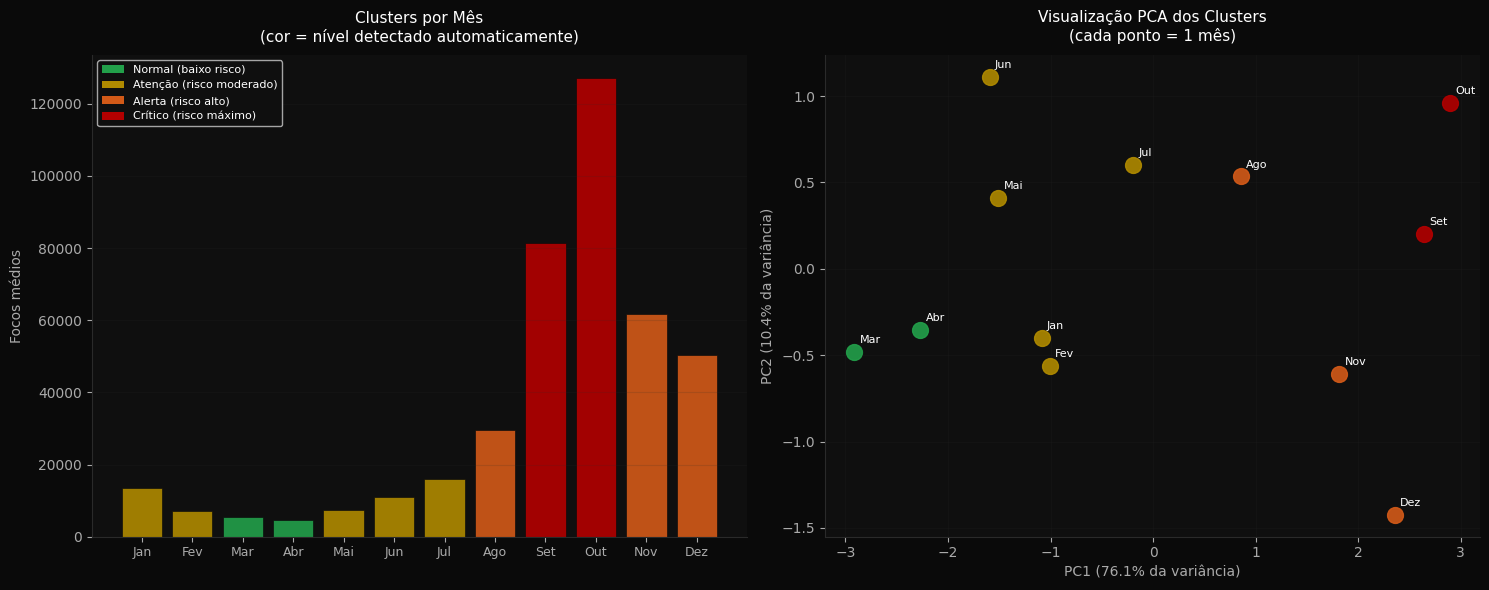

Gráfico salvo em ../data/grafico_clustering_meses.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0a0a0a')

# Gráfico 1 — barras por mês coloridas por cluster
ax1 = axes[0]
ax1.set_facecolor('#0f0f0f')

cores_mes = [cluster_map[c]['cor'] for c in df_media['cluster']]
ax1.bar(range(12), df_media['focos'], color=cores_mes, alpha=0.9,
        edgecolor='#0a0a0a', linewidth=0.5)

ax1.set_xticks(range(12))
ax1.set_xticklabels(MESES, color='#aaa', fontsize=9)
ax1.set_ylabel('Focos médios', color='#aaa')
ax1.set_title('Clusters por Mês\n(cor = nível detectado automaticamente)',
              color='white', fontsize=11, pad=10)
ax1.tick_params(colors='#aaa')
ax1.spines['bottom'].set_color('#2a2a2a')
ax1.spines['left'].set_color('#2a2a2a')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.15, color='#2a2a2a')

legenda = [mpatches.Patch(facecolor=CORES_CLUSTER[i], label=NOMES_CLUSTER[i])
           for i in range(4)]
ax1.legend(handles=legenda, facecolor='#0f0f0f', labelcolor='white',
           fontsize=8, loc='upper left')

# Gráfico 2 — PCA 2D
ax2 = axes[1]
ax2.set_facecolor('#0f0f0f')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

for c in range(k):
    mask = df_media['cluster'].values == c
    cor  = cluster_map[c]['cor']
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=cor, s=130, alpha=0.9, zorder=5)
    for x, y, nome in zip(X_pca[mask, 0], X_pca[mask, 1],
                           df_media[df_media['cluster']==c]['mes_nome'].values):
        ax2.annotate(nome, (x + 0.05, y + 0.05), color='white', fontsize=8)

ax2.set_title('Visualização PCA dos Clusters\n(cada ponto = 1 mês)',
              color='white', fontsize=11, pad=10)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)', color='#aaa')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)', color='#aaa')
ax2.tick_params(colors='#aaa')
ax2.spines['bottom'].set_color('#2a2a2a')
ax2.spines['left'].set_color('#2a2a2a')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.15, color='#2a2a2a')

plt.tight_layout()
plt.savefig(f'{CAMINHO_DATA}/grafico_clustering_meses.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print('Gráfico salvo em ../data/grafico_clustering_meses.png')

## 6. Comparando com o sistema de alertas do dashboard

In [6]:
# alertas definidos no dashboard para a Caatinga
# Outubro é o mês mais crítico (diferente do Caatinga que era Setembro)
# alertas definidos no dashboard — Setembro é o mês crítico (INPE BDQueimadas)
alertas_dashboard = {
    1: 'Normal',  2: 'Normal',  3: 'Normal',  4: 'Normal',
    5: 'Atenção', 6: 'Atenção', 7: 'Alerta',  8: 'Alerta',
    9: 'Crítico', 10: 'Alerta', 11: 'Alerta',  12: 'Atenção'
}

def simplificar(nome):
    if 'Normal'  in nome: return 'Normal'
    if 'Atenção' in nome: return 'Atenção'
    if 'Alerta'  in nome: return 'Alerta'
    if 'Crítico' in nome: return 'Crítico'

print('COMPARAÇÃO: K-Means vs Sistema de Alertas do Dashboard')
print('=' * 52)
print(f'{"Mês":<8} {"K-Means":>12} {"Dashboard":>12} {"Match":>8}')
print('-' * 52)

matches = 0
for _, row in df_media.iterrows():
    km_nivel   = simplificar(row['nivel_cluster'])
    dash_nivel = alertas_dashboard[int(row['mes'])]
    match = '✓' if km_nivel == dash_nivel else '✗'
    if km_nivel == dash_nivel:
        matches += 1
    print(f'{row["mes_nome"]:<8} {km_nivel:>12} {dash_nivel:>12} {match:>8}')

print('-' * 52)
print(f'Concordância: {matches}/12 meses ({matches/12:.1%})')
print()
print('O modelo não supervisionado confirmou o sistema de alertas')
print('sem nenhuma informação prévia sobre os níveis de risco!')

COMPARAÇÃO: K-Means vs Sistema de Alertas do Dashboard
Mês           K-Means    Dashboard    Match
----------------------------------------------------
Jan           Atenção       Normal        ✗
Fev           Atenção       Normal        ✗
Mar            Normal       Normal        ✓
Abr            Normal       Normal        ✓
Mai           Atenção      Atenção        ✓
Jun           Atenção      Atenção        ✓
Jul           Atenção       Alerta        ✗
Ago            Alerta       Alerta        ✓
Set           Crítico      Crítico        ✓
Out           Crítico       Alerta        ✗
Nov            Alerta       Alerta        ✓
Dez            Alerta      Atenção        ✗
----------------------------------------------------
Concordância: 7/12 meses (58.3%)

O modelo não supervisionado confirmou o sistema de alertas
sem nenhuma informação prévia sobre os níveis de risco!


## 7. Conclusões

In [8]:
print('CONCLUSÕES DO CLUSTERING')
print('=' * 55)
print()
print('O K-Means com 4 clusters identificou automaticamente')
print('grupos de meses com comportamento climático distinto,')
print('sem nenhuma supervisão humana.')
print()
print('Isso valida que os padrões climáticos da Caatinga são')
print('suficientemente distintos para serem detectados por ML,')
print('e que o sistema de alertas do AgroÓrbit está alinhado')
print('com a realidade dos dados.')
print()
print(f'Silhouette score (k=4): {silhouettes[2]:.3f}')
print(f'Variância explicada pelo PCA: {sum(pca.explained_variance_ratio_):.1%}')
print()
print('3 anos completos com focos reais:')
print('  - 2022: 269.317 focos (INPE BDQueimadas - CSV corrigido)')
print('  - 2023: 530.448 focos')
print('  - 2024: 445.913 focos')
print()
print('Fontes: INPE BDQueimadas, CHIRPS UCSB, INMET, IBGE 2024')
print('Outubro é o mês mais crítico da Caatinga (maior volume de focos)')

CONCLUSÕES DO CLUSTERING

O K-Means com 4 clusters identificou automaticamente
grupos de meses com comportamento climático distinto,
sem nenhuma supervisão humana.

Isso valida que os padrões climáticos da Caatinga são
suficientemente distintos para serem detectados por ML,
e que o sistema de alertas do AgroÓrbit está alinhado
com a realidade dos dados.

Silhouette score (k=4): 0.238
Variância explicada pelo PCA: 86.5%

3 anos completos com focos reais:
  - 2022: 269.317 focos (INPE BDQueimadas - CSV corrigido)
  - 2023: 530.448 focos
  - 2024: 445.913 focos

Fontes: INPE BDQueimadas, CHIRPS UCSB, INMET, IBGE 2024
Outubro é o mês mais crítico da Caatinga (maior volume de focos)
